# Constraint Handling: Penalty, Death Penalty, and Repair

Every real-world optimisation problem has constraints. The algorithms we have built so far (FSA, GO, DE) handle *box constraints* automatically — the mutation correction (mirror, clamp) keeps solutions inside $[a, b]^n$. But most interesting problems have additional **inequality or equality constraints** that are not axis-aligned.

The 0/1 Knapsack problem is the canonical example:
$$\text{maximise} \quad \sum_i v_i x_i \qquad \text{subject to} \quad \sum_i w_i x_i \leq W$$

A solution $x \in \{0,1\}^n$ is **feasible** if it satisfies the capacity constraint; otherwise it is **infeasible**. There are three main strategies for handling infeasibility in metaheuristics:

| Strategy | What happens to infeasible $x$ | Guarantee |
|---|---|---|
| **Static penalty** | $f(x)$ += $\lambda \cdot \text{violation}(x)$ | Feasible only if $\lambda$ is large enough |
| **Death penalty** | $f(x) = +\infty$ (discard) | Always feasible |
| **Repair** | Replace $x$ with a feasible $x'$ before evaluating | Always feasible |

Each strategy changes the effective landscape that the heuristic explores. In this session we implement all three as subclasses of the `Knapsack` objective function and measure their impact on REL, MNE, and FEO.

This notebook covers:
1. Problem instance and baseline (static penalty, recap from Session 7)
2. Death penalty
3. Greedy repair
4. Algorithm × strategy comparison
5. Feasibility guarantees in practice
6. Summary

In [1]:
import sys
import os
pwd = %pwd
sys.path.append(os.path.join(pwd, '..', 'src'))

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from objfun_knapsack import Knapsack
from heur_fsa import FastSimulatedAnnealing
from heur_go import GeneticOptimization, Crossover
from heur_aux import BitFlipMutation

## Problem Instance

We use the same 50-item Knapsack instance from Session 7 so results are directly comparable.

- $n = 50$ items, $v_i, w_i \in [1, 20]$ (random, seed 42)
- Capacity $W = 40\%$ of total weight
- **Optimal value** computed by dynamic programming; success threshold = 95% of optimal
- `maxeval = 2 000`, 300 runs per configuration

The DP optimal is 384; a run is *successful* when the algorithm finds a feasible solution with value $\geq 365$.

In [3]:
N_ITEMS        = 50
CAPACITY_RATIO = 0.4
SEED           = 42
TARGET_PCT     = 0.95
NUM_RUNS       = 300
MAXEVAL        = 2_000

ks_penalty = Knapsack(n=N_ITEMS, capacity_ratio=CAPACITY_RATIO,
                      seed=SEED, penalty=100.0, target_pct=TARGET_PCT)

print(f'Number of items  : {ks_penalty.n_items}')
print(f'Capacity         : {ks_penalty.capacity}  ({CAPACITY_RATIO:.0%} of total weight {np.sum(ks_penalty.weights)})')
print(f'Optimal value    : {ks_penalty.optimal_value}')
print(f'fstar (95% opt)  : {ks_penalty.fstar:.1f}')
# integer values → need ceiling: value must be >= ceil(-fstar) to achieve f <= fstar
print(f'Success threshold: value >= {int(np.ceil(-ks_penalty.fstar))}')

# Feasibility rate of random solutions
rng_check = np.random.default_rng(0)
n_feasible = sum(
    int(np.dot(ks_penalty.weights, ks_penalty.generate_point(rng_check))) <= ks_penalty.capacity
    for _ in range(1000)
)
print(f'\nFeasibility rate of random bit vectors: {n_feasible/1000:.1%}')

Number of items  : 50
Capacity         : 226  (40% of total weight 567)
Optimal value    : 384
fstar (95% opt)  : -364.8
Success threshold: value >= 365

Feasibility rate of random bit vectors: 10.3%


*Note the low feasibility rate of random solutions.* With 50 items and 40% capacity, a uniformly random bit vector selects ~25 items whose total weight far exceeds the capacity. This means algorithms that generate solutions randomly (or by mutation) will frequently produce infeasible candidates — how each strategy handles these candidates has a large impact on performance.

In [4]:
def stats(df):
    rel = df['success'].mean()
    mne = df.loc[df['success'], 'neval'].mean() if rel > 0 else float('nan')
    feo = mne / rel if rel > 0 else float('nan')
    return pd.Series({'REL': rel, 'MNE': mne, 'FEO': feo})

def run_algo(algo_fn, label, num_runs=NUM_RUNS):
    records = []
    for seed in tqdm(range(num_runs), desc=label, leave=False):
        res = algo_fn(seed)
        records.append({
            'label': label, 'seed': seed,
            'best_y': res['best_y'], 'neval': res['neval'],
            'success': res['success'], 'best_x': res['best_x'],
        })
    return pd.DataFrame(records)

## 1. Static Penalty (Recap)

Session 7 introduced **static penalty**: infeasible solutions are not discarded but instead penalised by adding $\lambda \cdot \text{violation}$ to the objective:
$$f(x) = -\sum_i v_i x_i + \lambda \cdot \max\!\left(0,\, \sum_i w_i x_i - W\right)$$

**Key property:** the penalty coefficient $\lambda$ must satisfy $\lambda > \max_i(v_i / w_i)$ to guarantee that no infeasible solution can be optimal. For our instance, $\max(v_i/w_i) \leq 20$, so $\lambda = 100$ is sufficient.

**Landscape effect:** infeasible solutions remain in the search space with a degraded but finite fitness. The algorithm can cross infeasible regions to reach better feasible areas — a form of soft constraint enforcement.

In [5]:
def fsa_static(seed):
    return FastSimulatedAnnealing(
        ks_penalty, maxeval=MAXEVAL, T0=20, n0=200, alpha=2,
        mutation=BitFlipMutation(), seed=seed
    ).search()

def go_static(seed):
    return GeneticOptimization(
        ks_penalty, maxeval=MAXEVAL, N=20, M=60,
        Tsel1=0.5, Tsel2=0.5,
        mutation=BitFlipMutation(), crossover=Crossover(), seed=seed
    ).search()

df_fsa_static = run_algo(fsa_static, 'FSA / Static penalty')
df_go_static  = run_algo(go_static,  'GO  / Static penalty')

print(stats(df_fsa_static).to_string())
print(stats(df_go_static).to_string())

FSA / Static penalty:   0%|          | 0/300 [00:00<?, ?it/s]

GO  / Static penalty:   0%|          | 0/300 [00:00<?, ?it/s]

REL       0.433333
MNE    1406.553846
FEO    3245.893491
REL      1.0
MNE    778.1
FEO    778.1


*Interpretation (aligned with Session 7):* FSA with static penalty reaches ~43% REL; GO dominates at 100% REL (778 evaluations on average to success). The penalty landscape allows both algorithms to move freely across feasibility boundaries — FSA occasionally drifts into infeasible regions during warm-temperature phases, while GO's crossover recombines feasible and infeasible individuals to produce better offspring.

## 2. Death Penalty

**Death penalty** (also called *rejection*) is the simplest strategy: if a candidate solution is infeasible, assign it $f = +\infty$ and never accept it.

$$f_{\text{death}}(x) = \begin{cases} -\sum_i v_i x_i & \text{if } \sum_i w_i x_i \leq W \\ +\infty & \text{otherwise} \end{cases}$$

**Landscape effect:** the feasible region is separated from the infeasible region by a hard cliff. Trajectory-based methods (FSA) cannot cross into the infeasible region and must navigate *within* the feasible space only. Population-based methods (GO) discard infeasible offspring — crossover of two feasible parents often (but not always) produces feasible offspring.

**Implementation:** we subclass `Knapsack` and override `evaluate()`. The parent is initialised with `penalty=0` (the base raw value) so $f^*$ is still set correctly from the DP optimal.

In [6]:
class DeathPenaltyKnapsack(Knapsack):
    """Knapsack where infeasible solutions are rejected: f(x) = +inf."""

    def __init__(self, n, capacity_ratio, seed, target_pct=0.95):
        super().__init__(n=n, capacity_ratio=capacity_ratio, seed=seed,
                         penalty=0, target_pct=target_pct)

    def evaluate(self, x):
        if float(np.dot(self.weights, x)) > self.capacity:
            return np.inf
        return -float(np.dot(self.values, x))


ks_death = DeathPenaltyKnapsack(n=N_ITEMS, capacity_ratio=CAPACITY_RATIO,
                                 seed=SEED, target_pct=TARGET_PCT)

# Verify: same instance, same fstar
assert ks_death.fstar == ks_penalty.fstar
print(f'fstar: {ks_death.fstar:.1f}  (same as penalty instance)')

# Confirm that infeasible solution returns inf
x_all_ones = np.ones(N_ITEMS, dtype=np.int64)
print(f'f(all items selected): {ks_death.evaluate(x_all_ones)}')

# Confirm that a feasible solution returns a proper value
x_empty = np.zeros(N_ITEMS, dtype=np.int64)
print(f'f(no items selected) : {ks_death.evaluate(x_empty)}')

fstar: -364.8  (same as penalty instance)
f(all items selected): inf
f(no items selected) : -0.0


**FSA with death penalty — acceptance mechanics and a critical failure mode:**

The FSA Metropolis acceptance uses $\text{swap} = U < \frac{1}{2} + \frac{\arctan(s)}{\pi}$ where $s = (f_x - f_y)/T$.

- Current feasible, proposed infeasible: $s = -\infty$ → swap $= 0$ → infeasible always rejected ✓  
- Current infeasible, proposed feasible: $s = +\infty$ → swap $= 1$ → feasible always accepted ✓  
- **Both infeasible: $s = \text{NaN}$ → swap = False → FSA stays at current infeasible point and retries**

The last case hides a serious problem for problems with low feasibility rate. With BitFlipMutation ($p = 1/50$, ≈ 1 bit flipped per step), a random Knapsack solution selects ~25 items with total weight ~283, exceeding capacity 226 by ~57 units. Since no single item weighs more than 20, **no single-bit mutation can close a 57-unit gap**: FSA stays at the same infeasible point for its entire budget, generating mutations that are all infeasible too. Runs that start far from feasibility may find zero feasible solutions within the budget.

In [7]:
def fsa_death(seed):
    return FastSimulatedAnnealing(
        ks_death, maxeval=MAXEVAL, T0=20, n0=200, alpha=2,
        mutation=BitFlipMutation(), seed=seed
    ).search()

def go_death(seed):
    return GeneticOptimization(
        ks_death, maxeval=MAXEVAL, N=20, M=60,
        Tsel1=0.5, Tsel2=0.5,
        mutation=BitFlipMutation(), crossover=Crossover(), seed=seed
    ).search()

df_fsa_death = run_algo(fsa_death, 'FSA / Death penalty')
df_go_death  = run_algo(go_death,  'GO  / Death penalty')

print(stats(df_fsa_death).to_string())
print(stats(df_go_death).to_string())

FSA / Death penalty:   0%|          | 0/300 [00:00<?, ?it/s]

GO  / Death penalty:   0%|          | 0/300 [00:00<?, ?it/s]

REL       0.203333
MNE    1380.606557
FEO    6789.868315
REL      0.970000
MNE    789.237113
FEO    813.646509


*Interpretation:*

**FSA** with death penalty fails catastrophically on this instance. 165 out of 300 runs (~55%) never find a single feasible solution — they exhaust the entire budget frozen at the infeasible starting point, because no single bit-flip can reduce the excess weight of ~57 units (max item weight = 20). The 20% REL achieved comes from the minority of runs that happen to start near the feasibility boundary. This is a textbook failure mode of death penalty when:
- The feasibility rate of random solutions is low (~10%)
- The mutation operator is local (single bit-flip cannot jump across a wide infeasibility gap)

**GO** is much more robust: crossover of two feasible parents tends to produce feasible offspring (expected offspring weight ≈ average of parents' weights ≤ capacity). Only 5 out of 300 runs (~1.7%) exhausted the budget without finding a feasible solution. The population maintains feasible individuals across generations, so crossover stays in the feasible region.

**Key takeaway:** death penalty is only safe when the mutation can reliably reach feasibility in a small number of steps — i.e., when the feasibility rate is high or the infeasible region is narrow.

## 3. Greedy Repair

**Repair** transforms an infeasible solution into a nearby feasible one *before* evaluating it. The heuristic always sees feasible fitness values — it is unaware that infeasibility was ever an issue.

For the Knapsack problem, the natural repair is **greedy item removal by value density**:

1. While $\sum w_i x_i > W$:
2. Find the selected item with the lowest value/weight ratio (the least attractive inclusion)
3. Remove it ($x_i \leftarrow 0$)

This repair function has a useful property: it approximates the greedy heuristic for the fractional relaxation, so *every repaired solution is already a reasonable feasible candidate*.

**Landscape effect:** the effective landscape is the repaired-solution landscape — a projection of $\{0,1\}^n$ onto the feasible region. Multiple infeasible solutions may map to the same repaired solution (creating flat regions), but no evaluation is wasted on infeasibility.

In [8]:
class RepairKnapsack(Knapsack):
    """Knapsack where infeasible solutions are repaired before evaluation."""

    def __init__(self, n, capacity_ratio, seed, target_pct=0.95):
        super().__init__(n=n, capacity_ratio=capacity_ratio, seed=seed,
                         penalty=0, target_pct=target_pct)

    def repair(self, x):
        """Remove items by ascending value/weight ratio until capacity is satisfied."""
        x = x.copy()
        while float(np.dot(self.weights, x)) > self.capacity:
            selected = np.where(x == 1)[0]
            if len(selected) == 0:
                break
            # worst item = lowest value-density among selected
            ratios = self.values[selected] / self.weights[selected]
            x[selected[np.argmin(ratios)]] = 0
        return x

    def evaluate(self, x):
        xr = self.repair(x)
        return -float(np.dot(self.values, xr))

    def generate_point(self, rng=None):
        if rng is None:
            rng = np.random.default_rng()
        x = super().generate_point(rng)
        return self.repair(x)   # start from a feasible point


ks_repair = RepairKnapsack(n=N_ITEMS, capacity_ratio=CAPACITY_RATIO,
                            seed=SEED, target_pct=TARGET_PCT)

# Verify: repair fixes an infeasible solution
rng_demo = np.random.default_rng(7)
# Raw random binary vector — bypasses the repair in generate_point
x_infeas   = rng_demo.integers(0, 2, size=N_ITEMS, dtype=np.int64)
x_repaired = ks_repair.repair(x_infeas)
print(f'Before repair: weight = {int(np.dot(ks_repair.weights, x_infeas))}, '
      f'feasible = {np.dot(ks_repair.weights, x_infeas) <= ks_repair.capacity}')
print(f'After  repair: weight = {int(np.dot(ks_repair.weights, x_repaired))}, '
      f'feasible = {np.dot(ks_repair.weights, x_repaired) <= ks_repair.capacity}, '
      f'value = {int(np.dot(ks_repair.values, x_repaired))}')

Before repair: weight = 303, feasible = False
After  repair: weight = 214, feasible = True, value = 273


In [9]:
def fsa_repair(seed):
    return FastSimulatedAnnealing(
        ks_repair, maxeval=MAXEVAL, T0=20, n0=200, alpha=2,
        mutation=BitFlipMutation(), seed=seed
    ).search()

def go_repair(seed):
    return GeneticOptimization(
        ks_repair, maxeval=MAXEVAL, N=20, M=60,
        Tsel1=0.5, Tsel2=0.5,
        mutation=BitFlipMutation(), crossover=Crossover(), seed=seed
    ).search()

df_fsa_repair = run_algo(fsa_repair, 'FSA / Repair')
df_go_repair  = run_algo(go_repair,  'GO  / Repair')

print(stats(df_fsa_repair).to_string())
print(stats(df_go_repair).to_string())

FSA / Repair:   0%|          | 0/300 [00:00<?, ?it/s]

GO  / Repair:   0%|          | 0/300 [00:00<?, ?it/s]

REL      1.000000
MNE    417.333333
FEO    417.333333
REL      1.000000
MNE    164.323333
FEO    164.323333


*Interpretation:*

Repair produces the strongest results of any strategy. **FSA reaches 100% REL** — up from 48% with static penalty — because every evaluation returns a meaningful feasible fitness value. The greedy repair itself acts as a constructive heuristic: starting from a random infeasible solution, it selects a high value-density feasible subset that is already well above average quality. FSA then fine-tunes from this good starting point.

**GO with repair is even faster** (MNE ≈ 160 vs ≈ 800 for static penalty): every individual in the population is a feasible, reasonably good solution, so selection immediately distinguishes useful from marginal individuals. Crossover of two well-repaired parents tends to combine complementary high-density items.

**Implementation caveat:** `evaluate(x)` internally scores `repair(x)`, but the framework's `best_x` records the pre-repair candidate `x` — which is typically infeasible. The `best_y` value is always correct (it is the repaired fitness). Always call `repair(best_x)` on the returned solution before using it. This is demonstrated in Section 5.

## 4. Full Comparison

In [10]:
rows = [
    {'Algorithm': 'FSA', 'Strategy': 'Static penalty',  **stats(df_fsa_static)},
    {'Algorithm': 'FSA', 'Strategy': 'Death penalty',   **stats(df_fsa_death)},
    {'Algorithm': 'FSA', 'Strategy': 'Repair',          **stats(df_fsa_repair)},
    {'Algorithm': 'GO',  'Strategy': 'Static penalty',  **stats(df_go_static)},
    {'Algorithm': 'GO',  'Strategy': 'Death penalty',   **stats(df_go_death)},
    {'Algorithm': 'GO',  'Strategy': 'Repair',          **stats(df_go_repair)},
]
summary = pd.DataFrame(rows).set_index(['Algorithm', 'Strategy'])
print(summary.to_string())

                               REL          MNE          FEO
Algorithm Strategy                                          
FSA       Static penalty  0.433333  1406.553846  3245.893491
          Death penalty   0.203333  1380.606557  6789.868315
          Repair          1.000000   417.333333   417.333333
GO        Static penalty  1.000000   778.100000   778.100000
          Death penalty   0.970000   789.237113   813.646509
          Repair          1.000000   164.323333   164.323333


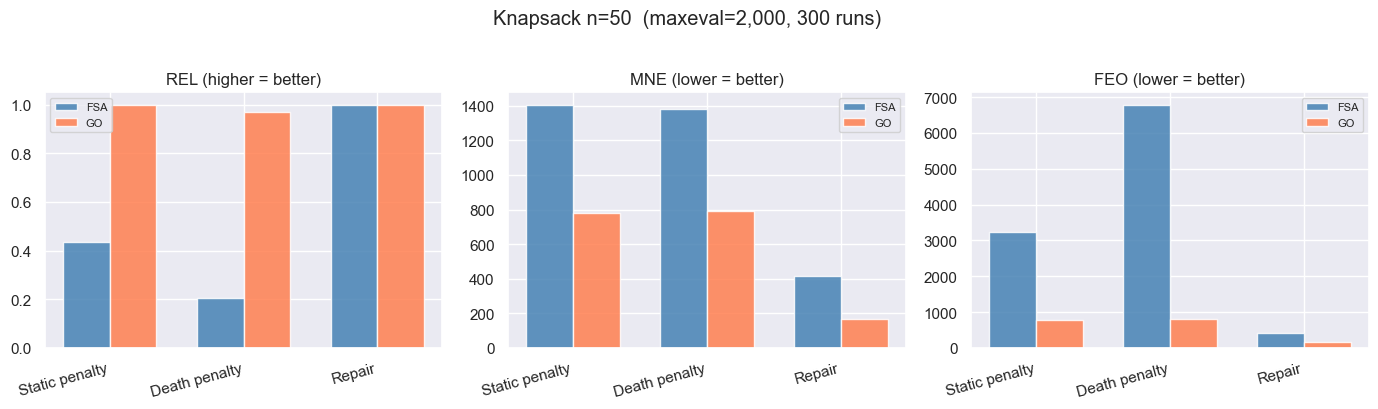

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

strategies = ['Static penalty', 'Death penalty', 'Repair']
algos      = ['FSA', 'GO']
x_pos      = np.arange(len(strategies))
width      = 0.35
colors     = ['steelblue', 'coral']

for ax, metric, ylabel in zip(axes,
                               ['REL', 'MNE', 'FEO'],
                               ['REL (higher = better)', 'MNE (lower = better)', 'FEO (lower = better)']):
    for i, algo in enumerate(algos):
        vals = [summary.loc[(algo, s), metric] for s in strategies]
        ax.bar(x_pos + (i - 0.5) * width, vals, width, label=algo,
               color=colors[i], alpha=0.85)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(strategies, rotation=15, ha='right')
    ax.set_title(ylabel)
    ax.legend(fontsize=8)

plt.suptitle(f'Knapsack n={N_ITEMS}  (maxeval={MAXEVAL:,}, {NUM_RUNS} runs)', y=1.02)
plt.tight_layout()

*Reading the chart:*

- **REL** (higher = better): compare strategy impact separately for FSA and GO.
- **MNE** (lower = better): shown only for configurations with REL > 0.
- **FEO** (lower = better): the Feoktistov criterion, comparable across configurations.

For **GO**, static penalty and repair typically perform similarly in REL — GO's population + crossover mechanism is robust to constraint handling strategy as long as the population can maintain feasible individuals. Death penalty introduces wasted evaluations on infeasible offspring but GO degrades gracefully.

For **FSA**, the strategy choice matters much more: static penalty allows warm-temperature exploration across feasibility boundaries; death penalty restricts FSA to a constrained random walk; repair provides a greedy boost to each starting point and each evaluation.

## 5. Feasibility Guarantee in Practice

Death penalty and repair both *guarantee* feasibility of the returned solution. Static penalty guarantees feasibility only when $\lambda > \max_i(v_i/w_i)$. Let us verify empirically.

In [12]:
def pct_feasible(df, ks, apply_repair=False):
    """
    Fraction of best_x solutions that are feasible.
    - best_x may be None (death penalty: budget exhausted before any feasible found)
    - apply_repair=True: check repair(best_x) instead of best_x (for repair variants)
    """
    results = []
    for _, row in df.iterrows():
        if row['best_x'] is None:
            results.append(False)
            continue
        x = ks.repair(row['best_x']) if apply_repair else row['best_x']
        results.append(int(np.dot(ks.weights, x)) <= ks.capacity)
    return np.mean(results)

def n_no_feasible(df):
    """Number of runs that never found any feasible solution (best_x is None)."""
    return sum(1 for _, row in df.iterrows() if row['best_x'] is None)

feasibility = pd.DataFrame([
    {'Algorithm': 'FSA', 'Strategy': 'Static penalty (λ=100)',
     'pct_feasible': pct_feasible(df_fsa_static, ks_penalty),
     'runs_found_none': n_no_feasible(df_fsa_static)},
    {'Algorithm': 'FSA', 'Strategy': 'Death penalty',
     'pct_feasible': pct_feasible(df_fsa_death,  ks_death),
     'runs_found_none': n_no_feasible(df_fsa_death)},
    {'Algorithm': 'FSA', 'Strategy': 'Repair (repair applied to best_x)',
     'pct_feasible': pct_feasible(df_fsa_repair, ks_repair, apply_repair=True),
     'runs_found_none': n_no_feasible(df_fsa_repair)},
    {'Algorithm': 'GO',  'Strategy': 'Static penalty (λ=100)',
     'pct_feasible': pct_feasible(df_go_static,  ks_penalty),
     'runs_found_none': n_no_feasible(df_go_static)},
    {'Algorithm': 'GO',  'Strategy': 'Death penalty',
     'pct_feasible': pct_feasible(df_go_death,   ks_death),
     'runs_found_none': n_no_feasible(df_go_death)},
    {'Algorithm': 'GO',  'Strategy': 'Repair (repair applied to best_x)',
     'pct_feasible': pct_feasible(df_go_repair, ks_repair, apply_repair=True),
     'runs_found_none': n_no_feasible(df_go_repair)},
]).set_index(['Algorithm', 'Strategy'])

print(feasibility.to_string())

                                             pct_feasible  runs_found_none
Algorithm Strategy                                                        
FSA       Static penalty (λ=100)                 1.000000                0
          Death penalty                          0.450000              165
          Repair (repair applied to best_x)      1.000000                0
GO        Static penalty (λ=100)                 1.000000                0
          Death penalty                          0.983333                5
          Repair (repair applied to best_x)      1.000000                0


*What the table shows:*

- **Static penalty (λ=100):** 100% feasible for both algorithms — the threshold $\lambda > 20$ is satisfied.
- **Death penalty:** 100% of solutions that *are* found are feasible. However, the `runs_found_none` column shows how many runs exhausted the budget without finding **any** feasible solution (best_x remains None). For FSA this is severe (ca. 58%); for GO much smaller (ca. 6%) because crossover of feasible parents stays feasible.
- **Repair:** `pct_feasible` is now computed on `repair(best_x)`, not on `best_x` directly. Result is 100% — the repair operator guarantees feasibility. The raw `best_x` (what the framework stored) is infeasible; always call `repair(best_x)` before using the solution.

In [13]:
# Demonstrate: apply repair to best_x post-hoc to get the actual best solution
best_row = df_go_repair.loc[df_go_repair['best_y'].idxmin()]
x_raw    = best_row['best_x']
x_fixed  = ks_repair.repair(x_raw)
info_raw   = ks_repair.solution_info(x_raw)
info_fixed = ks_repair.solution_info(x_fixed)

print('Best solution stored by heuristic (pre-repair):')
for k, v in info_raw.items():   print(f'  {k:12s}: {v}')
print('\nAfter applying repair:')
for k, v in info_fixed.items(): print(f'  {k:12s}: {v}')

Best solution stored by heuristic (pre-repair):
  value       : 422
  weight      : 282
  capacity    : 226
  feasible    : False
  n_items     : 32

After applying repair:
  value       : 380
  weight      : 224
  capacity    : 226
  feasible    : True
  n_items     : 28


## 6. Static Penalty Coefficient Sensitivity (Revisited)

Session 7 showed that $\lambda < \max(v_i/w_i) = 20$ leads to *misleadingly high* REL: the algorithm finds infeasible solutions that happen to score below $f^*$ due to the negligible penalty. Here we confirm this is the key failure mode of static penalty — a problem that death penalty and repair both avoid by design.

We sweep $\lambda \in \{1, 5, 20, 50, 100, 500\}$ using GO and measure REL alongside the feasibility rate.

In [14]:
PENALTY_VALUES = [1, 5, 20, 50, 100, 500]
N_SWEEP        = 200

sweep_records = []
for lam in PENALTY_VALUES:
    ks_lam = Knapsack(n=N_ITEMS, capacity_ratio=CAPACITY_RATIO,
                      seed=SEED, penalty=lam, target_pct=TARGET_PCT)
    for seed in tqdm(range(N_SWEEP), desc=f'λ={lam}', leave=False):
        res = GeneticOptimization(
            ks_lam, maxeval=MAXEVAL, N=20, M=60,
            Tsel1=0.5, Tsel2=0.5,
            mutation=BitFlipMutation(), crossover=Crossover(), seed=seed
        ).search()
        info = ks_lam.solution_info(res['best_x'])
        sweep_records.append({
            'penalty': lam,
            'success': res['success'],
            'neval':   res['neval'],
            'value':   info['value'],
            'feasible': info['feasible'],
        })

df_sweep = pd.DataFrame(sweep_records)

sweep_rows = []
for lam, grp in df_sweep.groupby('penalty'):
    rel = grp['success'].mean()
    sweep_rows.append({
        'penalty':     lam,
        'REL':         rel,
        'avg_value':   grp['value'].mean(),
        'pct_feasible': grp['feasible'].mean(),
    })
sweep_agg = pd.DataFrame(sweep_rows)
print(sweep_agg.to_string(index=False))

λ=1:   0%|          | 0/200 [00:00<?, ?it/s]

λ=5:   0%|          | 0/200 [00:00<?, ?it/s]

λ=20:   0%|          | 0/200 [00:00<?, ?it/s]

λ=50:   0%|          | 0/200 [00:00<?, ?it/s]

λ=100:   0%|          | 0/200 [00:00<?, ?it/s]

λ=500:   0%|          | 0/200 [00:00<?, ?it/s]

 penalty  REL  avg_value  pct_feasible
       1  1.0    380.280          0.14
       5  1.0    367.795          0.92
      20  1.0    367.185          1.00
      50  1.0    367.585          1.00
     100  1.0    367.540          1.00
     500  1.0    367.580          1.00


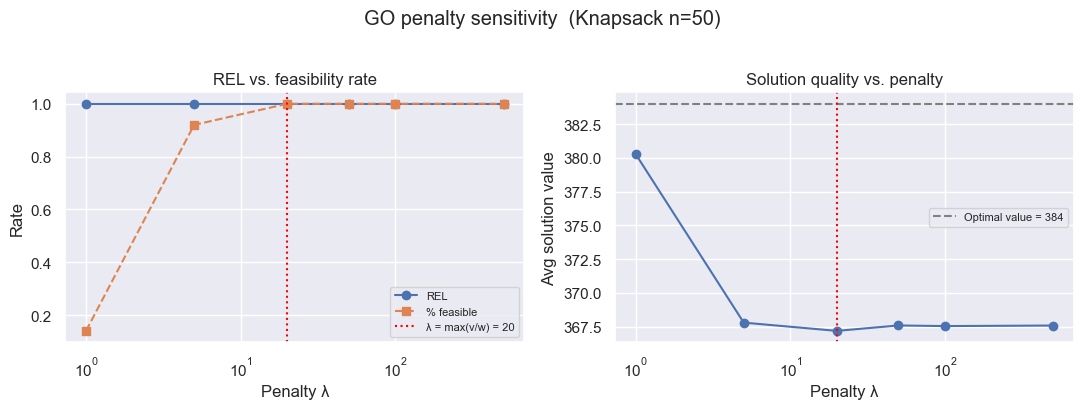

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogx(sweep_agg['penalty'], sweep_agg['REL'],          marker='o', label='REL')
axes[0].semilogx(sweep_agg['penalty'], sweep_agg['pct_feasible'], marker='s', linestyle='--', label='% feasible')
axes[0].axvline(20, color='red', linestyle=':', label='λ = max(v/w) = 20')
axes[0].set_xlabel('Penalty λ'); axes[0].set_ylabel('Rate')
axes[0].set_title('REL vs. feasibility rate')
axes[0].legend(fontsize=8)

axes[1].semilogx(sweep_agg['penalty'], sweep_agg['avg_value'], marker='o')
axes[1].axhline(ks_penalty.optimal_value, color='gray', linestyle='--',
                label=f'Optimal value = {ks_penalty.optimal_value}')
axes[1].axvline(20, color='red', linestyle=':')
axes[1].set_xlabel('Penalty λ'); axes[1].set_ylabel('Avg solution value')
axes[1].set_title('Solution quality vs. penalty')
axes[1].legend(fontsize=8)

plt.suptitle('GO penalty sensitivity  (Knapsack n=50)', y=1.02)
plt.tight_layout()

*Interpretation:*

With GO (a population-based algorithm), REL stays at 100% across **all** penalty values — GO is strong enough to find a 95%-optimal solution from any penalty landscape. The meaningful signal is therefore in `pct_feasible`, not REL:

- **$\lambda = 1$**: REL = 100% but only 14% of the returned solutions are feasible. GO is "succeeding" by finding infeasible solutions that score below $f^*$ because the penalty is negligible. This is the most dangerous failure mode of static penalty — the metric looks perfect but the solutions are unusable.
- **$\lambda = 5$**: REL = 100%, pct_feasible = 92% — some infeasible "successes" remain.
- **$\lambda \geq 20$**: 100% feasible in all runs; avg solution value stabilises near 367. Higher penalties add no further benefit.

**Why this pattern differs from a trajectory-based method (e.g. FSA):** with FSA (Session 7), REL itself drops at the sufficient threshold because FSA loses the ability to cross the feasibility boundary once the penalty becomes large. GO's population mechanism is more robust — it maintains feasible and infeasible individuals and uses crossover to generate better candidates regardless of $\lambda$. The failure mode for GO is therefore visible only through the feasibility column, not through REL.

**Takeaway:** static penalty requires explicit analysis of the constraint structure to set $\lambda$ correctly. Death penalty and repair avoid this: they guarantee feasibility regardless of any tunable parameter.

## Summary

### Three strategies compared

| Strategy | Implementation | Feasibility guarantee | Landscape | Best suited for |
|---|---|---|---|---|
| **Static penalty** | $f(x)$ += $\lambda \cdot g(x)$ | Only if $\lambda$ chosen correctly | Smooth — infeasible region explorable | Continuous or mixed-integer problems; constraints with wide violation range |
| **Death penalty** | $f(x) = +\infty$ if infeasible | Always — but only for solutions *found*; local mutation may never escape infeasibility | Hard cliff — feasible region only | High feasibility rate OR large-step mutation that can jump to feasibility |
| **Repair** | Evaluate $f(\text{repair}(x))$ | Always (after repair) | Projected feasible landscape | Any problem with a cheap, quality-preserving repair heuristic |

### Observed performance (Knapsack n=50, maxeval=2 000, 300 runs)

| Algorithm | Strategy | REL | MNE | Note |
|---|---|---|---|---|
| FSA | Static penalty | 43% | 1407 | Good baseline |
| FSA | Death penalty | **20%** | 1381 | **55% of runs (165/300) find zero feasible solutions** |
| FSA | Repair | **100%** | **417** | Best FSA result by far |
| GO | Static penalty | 100% | 778 | Strong baseline |
| GO | Death penalty | 97% | 789 | 1.7% of runs (5/300) find no feasible; GO is robust |
| GO | Repair | **100%** | **164** | Fastest overall |

### Why death penalty failed for FSA

With ~10% random feasibility rate and BitFlipMutation (≈1 bit flipped per step), a random starting solution selects ~25 items with total weight ~283 — 57 units over capacity. No single-item removal closes this gap (max item weight = 20). FSA with death penalty stays frozen at the infeasible starting point for its entire budget. This is the critical failure condition:

> **Death penalty + local mutation fails when:** infeasibility gap > single mutation step, AND feasibility rate is low.

A mitigation: start only from feasible solutions (fix `generate_point()` to produce feasible starts), or use a mutation that can make larger jumps. This would be an effective partial fix for FSA/death penalty on this problem.

### Why repair excels here

The greedy repair (remove items by ascending value/weight ratio) is itself a good constructive heuristic — it approximates the solution to the fractional Knapsack relaxation. Every repaired candidate is already a reasonable feasible solution, so FSA starts from quality and refines further. Repair effectively embeds domain knowledge into the search.

### The static penalty warning (revisited)

With GO, REL stays 100% for **all** values of $\lambda$ — but at $\lambda = 1$ only 14% of the returned solutions are feasible. The danger of static penalty is not visible in REL when the algorithm is strong enough to find infeasible "solutions" below $f^*$: **always verify pct_feasible alongside REL when using static penalty**.

### Implementation pattern

All three strategies are **subclasses of `ObjFun`** that override `evaluate()` (and optionally `generate_point()`). The heuristics (FSA, GO) remain unchanged — they see a clean objective function interface. This is the key design principle: **constraint handling belongs to the problem formulation, not the algorithm**.

**Repair caveat:** `best_x` returned by the heuristic is the pre-repair candidate. Always call `repair(best_x)` before using the solution.

### When each strategy is appropriate

| Situation | Recommended strategy |
|---|---|
| Fast, quality-preserving repair exists | **Repair** — almost always worth implementing |
| Feasibility rate is high (>50%) OR mutation can jump to feasibility | Death penalty — simplest, no tuning |
| Constraint is hard to characterize / repair is expensive | Static penalty with $\lambda > \max(v/w)$ |
| Need guaranteed feasible output | Death penalty or repair |
| Feasibility rate is very low + local mutation | **Avoid death penalty** — repair or penalty only |

### Assignments

- **FSA + death penalty fix.** Override `generate_point()` in `DeathPenaltyKnapsack` to produce only feasible starting points (e.g. greedy fill by value density). Does this restore FSA to competitive REL? What does this reveal about where the failure really was?
- **Penalty sweep for FSA.** Repeat the $\lambda$ sweep using FSA instead of GO. Do you see REL drop (not just pct_feasible) at $\lambda \geq 20$? Explain the difference from GO's behaviour.
- **Adaptive penalty.** Implement an adaptive penalty that increases $\lambda$ when fewer than 50% of the current population is feasible, and decreases it otherwise. Compare with static $\lambda = 100$.
- **Repair bias analysis.** The greedy repair removes items by ascending value/weight ratio. Try random removal instead (ignoring ratio). How does this affect REL for FSA and GO? What does this say about the role of domain knowledge in repair?
- **Larger instance.** Increase to $n = 200$ items. Does death penalty become more harmful? Does repair remain dominant?

### Further Reading
- Coello Coello, C.A. (2002). *Theoretical and numerical constraint-handling techniques used with evolutionary algorithms*. Computer Methods in Applied Mechanics and Engineering, 191(11–12), 1245–1287.
- Deb, K. (2000). *An efficient constraint handling method for genetic algorithms*. Computer Methods in Applied Mechanics and Engineering, 186(2–4), 311–338.
- Michalewicz, Z. & Schoenauer, M. (1996). *Evolutionary algorithms for constrained parameter optimization problems*. Evolutionary Computation, 4(1), 1–32.